In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer 

In [2]:
df = pd.read_csv("clean_jobs.csv")
print(df.shape)
print(df.columns.tolist())
print(df["clean_description"].head())
print(df["clean_description"].isnull().sum())

(7996, 17)
['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length']
0    job description send me jobs like this qualifi...
1    job description send me jobs like this qualifi...
2    job description send me jobs like this as a de...
3    job description send me jobs like this involve...
4    job description send me jobs like this please ...
Name: clean_description, dtype: str
0


# create vectorizer

In [3]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english",
    max_features=3000,

    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

# Create matrix

In [4]:
x = vectorizer.fit_transform(df['clean_description'])
print("Matrix shape:",x.shape)

Matrix shape: (7996, 3000)


# features

In [5]:
terms = vectorizer.get_feature_names_out()
print("Number of terms:", len(terms))
print(terms[:50])

Number of terms: 3000
['abap' 'abilities' 'ability' 'ability understand' 'ability work' 'able'
 'able work' 'academic' 'access' 'accordance' 'according' 'account'
 'account management' 'accountable' 'accountant' 'accountant keyskills'
 'accounting' 'accounting finance' 'accounts' 'accounts executive'
 'accounts executive accountant' 'accounts finance' 'accounts finance tax'
 'accounts role' 'accounts role accounts' 'accuracy' 'accurate' 'achieve'
 'achievement' 'achieving' 'acirceurocent' 'acquisition' 'act' 'action'
 'actions' 'active' 'active directory' 'actively' 'activities' 'activity'
 'ad' 'add' 'added' 'added advantage' 'addition' 'additional'
 'additional information' 'address' 'adhere' 'adherence']


# calculate score

In [6]:
tfidf_scores = np.asarray(
    x.sum(axis=0)

).flatten()

In [7]:
ngram_df = pd.DataFrame({
    "term": terms,
    "tfidf_score": tfidf_scores
})

In [8]:
ngram_df = ngram_df.sort_values(
    by="tfidf_score",
    ascending=False
)
display(ngram_df.head(30))

,term,tfidf_score
2519,software,474.605362
776,doctorate,400.553001
1417,job,326.811740
956,experience,326.652528
2349,sales,323.942168
2279,role,308.558903
2052,profile,306.382308
689,description,289.006967
1418,job description,282.498968
2569,specialization,280.334358


# Separate Unigrams, Bigrams and Trigrams

In [9]:
unigrams = ngram_df[
    ngram_df["term"].str.split().str.len() ==1
]

In [10]:
bigrams = ngram_df[
    ngram_df["term"].str.split().str.len() == 2
]

In [11]:
trigrams = ngram_df[
    ngram_df["term"].str.split().str.len() == 3
]

# Top unigram

In [12]:
print("Top Unigrams")

display(
    unigrams.head(20)
)

Top Unigrams


,term,tfidf_score
2519,software,474.605362
776,doctorate,400.553001
1417,job,326.811740
956,experience,326.652528
2349,sales,323.942168
2279,role,308.558903
2052,profile,306.382308
689,description,289.006967
2569,specialization,280.334358
2217,required,259.452967


In [13]:
print("Top bigrams")

display(
    bigrams.head(20)
)

Top bigrams


,term,tfidf_score
1418,job description,282.498968
2573,specialization doctorate,164.591981
695,description send,149.313762
2423,send jobs,149.301415
1434,jobs like,149.301415
1136,graduation required,149.261978
341,candidate profile,146.445992
721,desired candidate,146.301456
1068,functional area,146.187185
491,company profile,145.804481


In [14]:
print("Top Trigrams")

display(
    trigrams.head(20)
)

Top Trigrams


,term,tfidf_score
1421,job description send,149.313762
2424,send jobs like,149.301415
696,description send jobs,149.301415
722,desired candidate profile,146.039094
1986,ppt photo view,145.014586
1932,photo view contact,145.014586
2906,view contact details,145.014586
797,download ppt photo,145.014586
342,candidate profile education,143.139904
2056,profile education ug,142.745909


In [15]:
taxonomy = pd.read_csv(
    "skill_taxonomy.csv"
)
taxonomy_skills = set(
    taxonomy["skill"]
    .dropna()
    .str.lower()
    .str.strip()
)

In [16]:
multiword_skills = ngram_df[
    ngram_df["term"].str.lower().isin(taxonomy_skills)
]

# show matching skills

In [17]:
multiword_skills = multiword_skills.sort_values(
    by="tfidf_score",
    ascending=False
)

display(
    multiword_skills.head(30)
)

,term,tfidf_score
474,communication,127.782405
295,bpo,118.084016
1412,java,110.134773
1816,operations,100.548116
1826,oracle,87.770553
2597,sql,87.155680
623,customer service,62.641590
1414,javascript,58.732109
890,english,52.290149
1374,internet,46.616094


In [18]:
multiword_skills = multiword_skills[
    multiword_skills["term"].str.split().str.len() >= 2
]
display(
    multiword_skills.head(30)
)

,term,tfidf_score
623,customer service,62.641590
625,customer support,23.407009
1738,ms office,20.217535
637,data entry,12.743627
636,data analysis,10.372636


# bigrams visualization

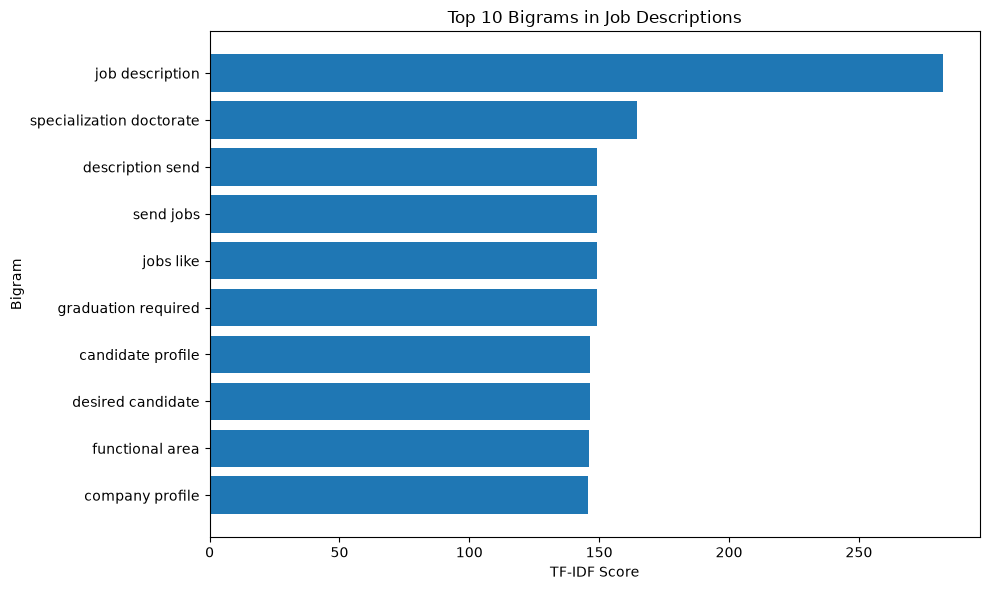

In [19]:
top_bigrams = bigrams.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_bigrams["term"][::-1],
    top_bigrams["tfidf_score"][::-1]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Bigram")
plt.title("Top 10 Bigrams in Job Descriptions")

plt.tight_layout()

# plt.savefig(
#     "top_10_bigrams.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# trigrams visualize

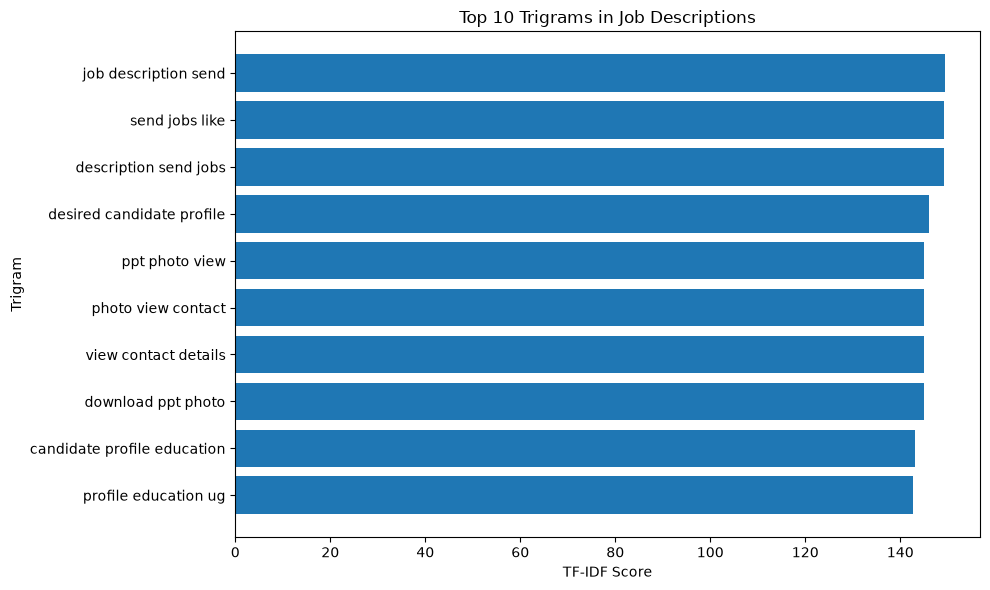

In [20]:
top_trigrams = trigrams.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_trigrams["term"][::-1],
    top_trigrams["tfidf_score"][::-1]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Trigram")
plt.title("Top 10 Trigrams in Job Descriptions")

plt.tight_layout()

# plt.savefig(
#     "top_10_trigrams.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

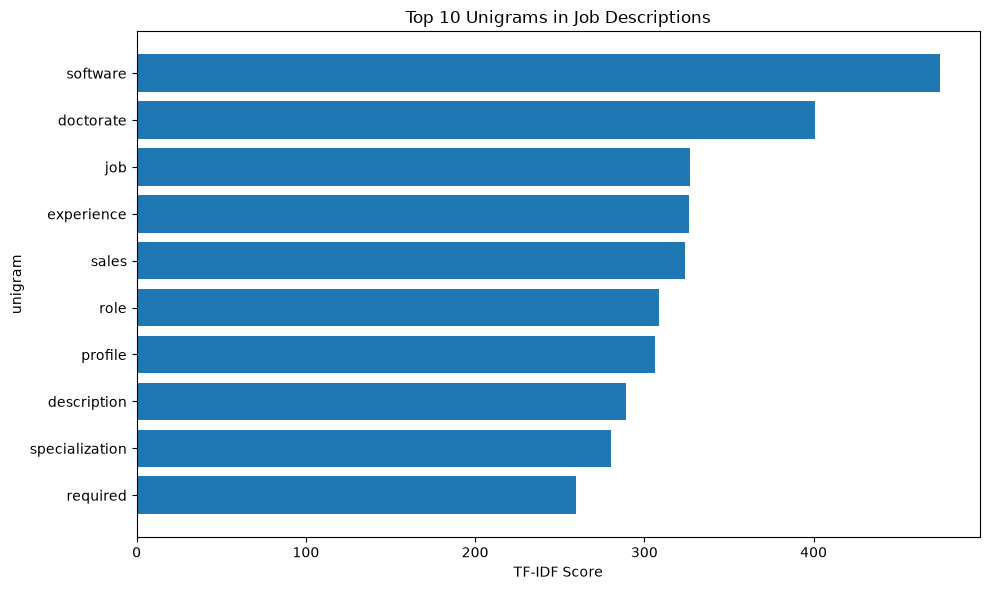

In [21]:
top_unigrams = unigrams.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_unigrams["term"][::-1],
    top_unigrams["tfidf_score"][::-1]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("unigram")
plt.title("Top 10 Unigrams in Job Descriptions")

plt.tight_layout()

# plt.savefig(
#     "top_10_trigrams.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# Day 11 Word Embeddings and Semantic Similarity 

In [22]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np 
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity 

In [34]:
df = pd.read_csv("clean_jobs_with_skills.csv")
taxonomy = pd.read_csv("skill_taxonomy.csv")

print(df.shape)
print(taxonomy.shape)

(7996, 20)
(101, 3)


# prepare taxonomy

In [35]:
taxonomy["skill"] = taxonomy["skill"].fillna("").astype(str).str.strip()

skills = taxonomy["skill"].tolist()

print("Total taxonomy skills:", len(skills))

Total taxonomy skills: 101


# load sentence transformer

In [36]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1103.04it/s]


# create taxonomy

In [37]:
skill_embeddings = model.encode(
    skills,
    batch_size=32,
    convert_to_numpy=True,
    show_progress_bar=True
)

print(skill_embeddings.shape)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches: 100%|██████████| 4/4 [00:01<00:00,  2.21it/s]

(101, 384)


# test

In [38]:
test_terms = [
    "ML",
    "Machine Learning",
    "AI",
    "Artificial Intelligence",
    "Python",
    "Excel",
    "postgres",
    "powerbi"
]

test_embeddings = model.encode(
    test_terms,
    convert_to_numpy=True
)

test_similarity = cosine_similarity(test_embeddings)

test_df = pd.DataFrame(
    test_similarity,
    index=test_terms,
    columns=test_terms
)

print(test_df.round(3))

                            ML  Machine Learning     AI  \
ML                       1.000             0.373  0.344   
Machine Learning         0.373             1.000  0.546   
AI                       0.344             0.546  1.000   
Artificial Intelligence  0.299             0.703  0.791   
Python                   0.288             0.361  0.399   
Excel                    0.334             0.383  0.280   
postgres                 0.211             0.232  0.134   
powerbi                  0.099             0.234  0.231   

                         Artificial Intelligence  Python  Excel  postgres  \
ML                                         0.299   0.288  0.334     0.211   
Machine Learning                           0.703   0.361  0.383     0.232   
AI                                         0.791   0.399  0.280     0.134   
Artificial Intelligence                    1.000   0.468  0.297     0.157   
Python                                     0.468   1.000  0.390     0.270   
Excel 

# extraction

In [39]:
def semantic_skill_extractor(text, threshold=0.50):

    if not text or not str(text).strip():
        return []

    text = str(text).lower()

    # Words + 2-word + 3-word phrases
    words = text.split()

    candidates = []

    # single words
    candidates.extend(words)

    # bigrams
    for i in range(len(words) - 1):
        candidates.append(
            words[i] + " " + words[i + 1]
        )

    # trigrams
    for i in range(len(words) - 2):
        candidates.append(
            words[i] + " " + words[i + 1] + " " + words[i + 2]
        )

    # remove duplicates
    candidates = list(set(candidates))

    # remove very short candidates
    candidates = [
        x for x in candidates
        if len(x) >= 3
    ]

    if not candidates:
        return []

    # Encode candidates
    candidate_embeddings = model.encode(
        candidates,
        batch_size=64,
        convert_to_numpy=True
    )

    # Compare candidates with taxonomy
    similarity_matrix = cosine_similarity(
        candidate_embeddings,
        skill_embeddings
    )

    found = []

    for i, candidate in enumerate(candidates):

        best_index = np.argmax(similarity_matrix[i])

        score = similarity_matrix[i][best_index]

        if score >= threshold:

            skill = skills[best_index]

            found.append({
                "skill": skill,
                "similarity": round(float(score), 3),
                "matched_text": candidate
            })

    # Remove duplicate skills
    unique = {}

    for item in found:

        skill = item["skill"]

        if (
            skill not in unique
            or item["similarity"] > unique[skill]["similarity"]
        ):
            unique[skill] = item

    return list(unique.values())

# new extraction

In [40]:
def semantic_skill_extractor(text, threshold=0.50):

    # Check empty text
    if pd.isna(text) or not str(text).strip():
        return []

    text = str(text).lower()

    # Create words
    words = text.split()

    candidates = []

    # Unigrams
    candidates.extend(words)

    # Bigrams
    for i in range(len(words) - 1):
        candidates.append(
            words[i] + " " + words[i + 1]
        )

    # Trigrams
    for i in range(len(words) - 2):
        candidates.append(
            words[i] + " "
            + words[i + 1] + " "
            + words[i + 2]
        )

    # Remove duplicates
    candidates = list(dict.fromkeys(candidates))

    # Remove very short candidates
    candidates = [
        candidate
        for candidate in candidates
        if len(candidate) >= 3
    ]

    if not candidates:
        return []

    # Create embeddings
    candidate_embeddings = model.encode(
        candidates,
        batch_size=64,
        convert_to_numpy=True,
        show_progress_bar=False
    )

    # Calculate similarity
    similarity_matrix = cosine_similarity(
        candidate_embeddings,
        skill_embeddings
    )

    found = []

    for i, candidate in enumerate(candidates):

        best_index = np.argmax(similarity_matrix[i])

        score = float(similarity_matrix[i][best_index])

        if score >= threshold:

            found.append({
                "skill": skills[best_index],
                "similarity": round(score, 3),
                "matched_text": candidate
            })

    # Keep highest score for each skill
    unique = {}

    for item in found:

        skill = item["skill"]

        if (
            skill not in unique
            or item["similarity"] > unique[skill]["similarity"]
        ):
            unique[skill] = item

    return list(unique.values())

In [41]:
test_text = df["clean_description"].iloc[2]

print("JOB DESCRIPTION:")
print(test_text[:1000])

result = semantic_skill_extractor(
    test_text,
    threshold=0.50
)

print("\nEXTRACTED SKILLS:")

for item in result:
    print(
        item["skill"],
        "->",
        item["similarity"],
        "->",
        item["matched_text"]
    )

JOB DESCRIPTION:
job description send me jobs like this as a developer in providing application design guidance and consultation utilizing a thorough understanding of applicable technology tools and existing designs analyzes highly complex business requirements designs and writes technical specifications to design or redesign complex computer platforms and applications provides coding direction to less experienced staff or develops highly complex original code acts as an expert technical resource for modeling simulation and analysis efforts verifies program logic by overseeing the preparation of test data testing and debugging of programs oversees overall systems testing and the migration of platforms and applications to production develops new documentation departmental technical procedures and user guides leads projects allocates and manages resources and manages the work of less experienced staff assures quality security and compliance requirements are met for supported area and ove

In [44]:
sample_df = df.head(100).copy()

sample_df["semantic_skills"] = sample_df["clean_description"].apply(
    lambda text: semantic_skill_extractor(
        text,
        threshold=0.50
    )
)

print(
    sample_df[
        ["jobtitle", "semantic_skills"]
    ].head(20).to_string(index=False)
)

                                                              jobtitle                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [45]:
print(
    "Rows with skills:",
    (sample_df["semantic_skills"].apply(len) > 0).sum()
)

print(
    "Empty rows:",
    (sample_df["semantic_skills"].apply(len) == 0).sum()
)

Rows with skills: 100
Empty rows: 0


In [56]:
test_text = df["clean_description"].iloc[2]

print("JOB DESCRIPTION:")
print(test_text[:1000])

print("\n" + "="*60)

result = semantic_skill_extractor(
    test_text,
    threshold=0.50
)

print("EXTRACTED SKILLS:")

for item in result:
    print(
        item["skill"],
        "->",
        item["similarity"],
        "->",
        item["matched_text"]
    )

readable_result = pd.DataFrame(result)

if not readable_result.empty:
    readable_result = readable_result[
        ["skill", "similarity", "matched_text"]
    ].sort_values(
        "similarity",
        ascending=False
    )

display(readable_result)

JOB DESCRIPTION:
job description send me jobs like this as a developer in providing application design guidance and consultation utilizing a thorough understanding of applicable technology tools and existing designs analyzes highly complex business requirements designs and writes technical specifications to design or redesign complex computer platforms and applications provides coding direction to less experienced staff or develops highly complex original code acts as an expert technical resource for modeling simulation and analysis efforts verifies program logic by overseeing the preparation of test data testing and debugging of programs oversees overall systems testing and the migration of platforms and applications to production develops new documentation departmental technical procedures and user guides leads projects allocates and manages resources and manages the work of less experienced staff assures quality security and compliance requirements are met for supported area and ove

,skill,similarity,matched_text
11,SQL,1.000,sql
3,Data Analysis,0.793,analysis
10,Network Security,0.758,security
0,Customer Service,0.718,services
19,Data Processing,0.701,data application
16,Data Entry,0.697,data using
7,Data Collection,0.688,data
5,Python,0.643,program
15,Computer Fundamentals,0.639,complex computer
2,Internet,0.629,computer


# ML vs Machine learning

In [57]:
ml_embedding = model.encode(
    ["ML"],
    convert_to_numpy=True
)

machine_learning_embedding = model.encode(
    ["Machine Learning"],
    convert_to_numpy=True
)

score = cosine_similarity(
    ml_embedding,
    machine_learning_embedding
)[0][0]

print("ML ↔ Machine Learning:", round(float(score), 3))

ML ↔ Machine Learning: 0.373


# actual comparison by taxonomy

In [58]:
test_embedding = model.encode(
    ["Machine Learning"],
    convert_to_numpy=True
)

scores = cosine_similarity(
    test_embedding,
    skill_embeddings
)[0]

result = pd.DataFrame({
    "skill": skills,
    "cosine_similarity": scores
})

result = result.sort_values(
    "cosine_similarity",
    ascending=False
)

print(result.head(10))

                           skill  cosine_similarity
94              Machine Learning           1.000000
99       Artificial Intelligence           0.703463
95                 Deep Learning           0.688687
100                Data Analysis           0.554489
82               Data Processing           0.537508
96                  Data Science           0.532431
98               Computer Vision           0.518386
97   Natural Language Processing           0.481670
71      Basic Computer Knowledge           0.416780
58                           NLP           0.415969
